In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv(r"C:\Users\shaza_hm8\OneDrive\Desktop\calories.csv")

In [3]:
df

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0
...,...,...,...,...,...,...,...,...,...
14995,15644082,female,20,193.0,86.0,11.0,92.0,40.4,45.0
14996,17212577,female,27,165.0,65.0,6.0,85.0,39.2,23.0
14997,17271188,female,43,159.0,58.0,16.0,90.0,40.1,75.0
14998,18643037,male,78,193.0,97.0,2.0,84.0,38.3,11.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


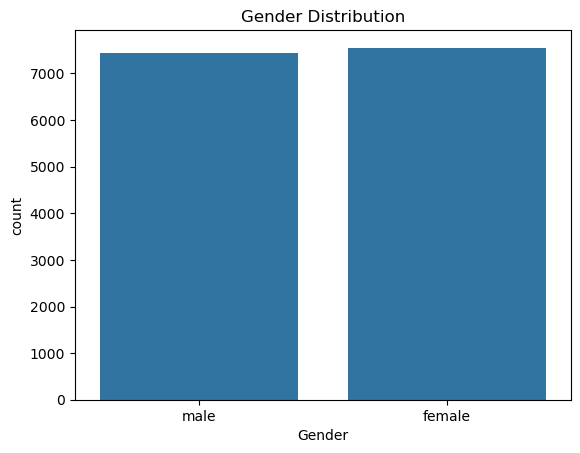

In [5]:
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

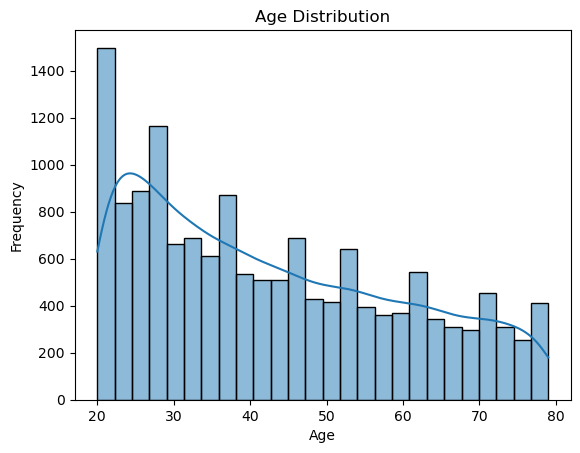

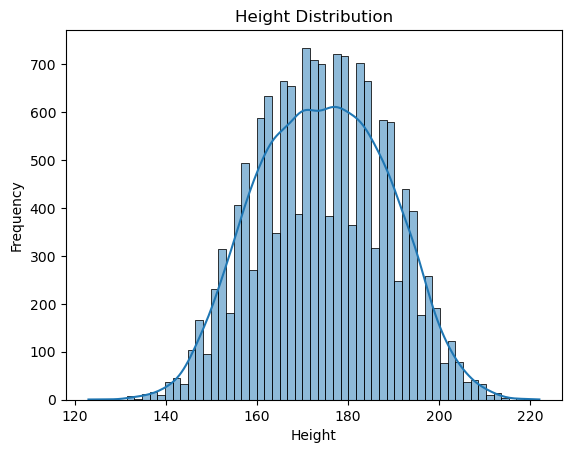

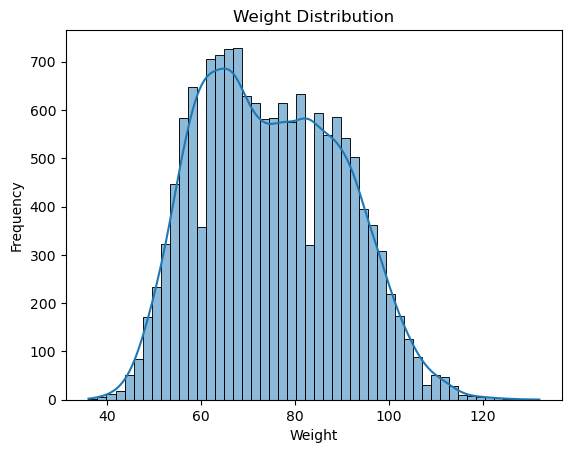

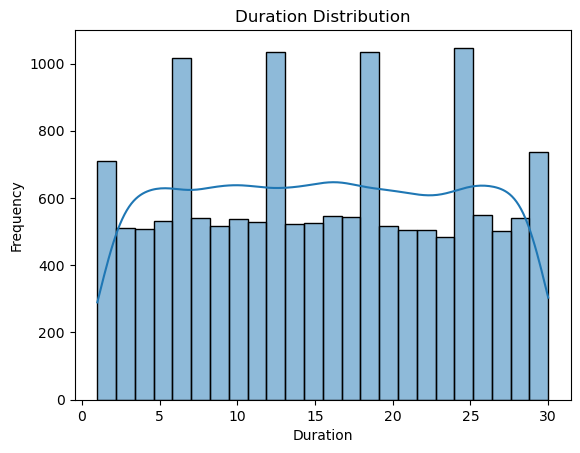

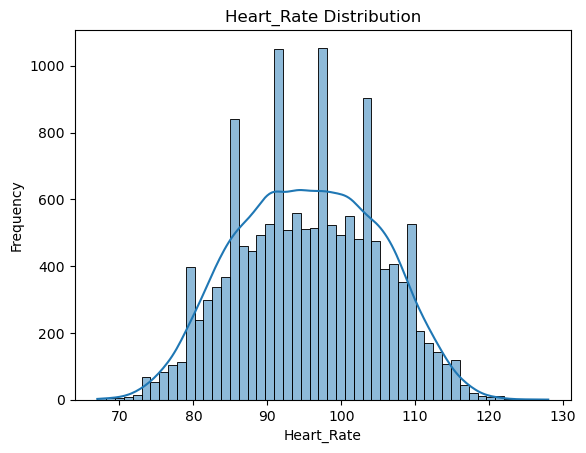

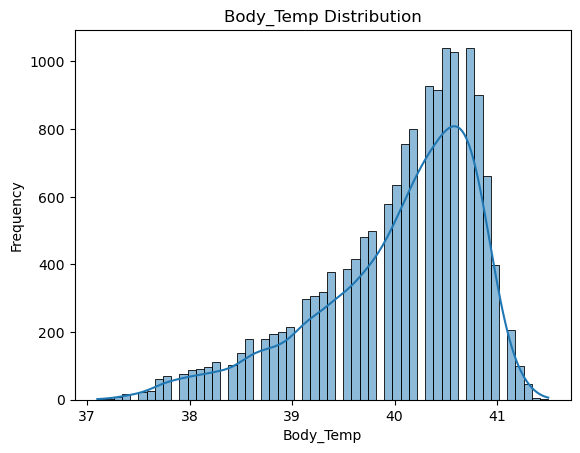

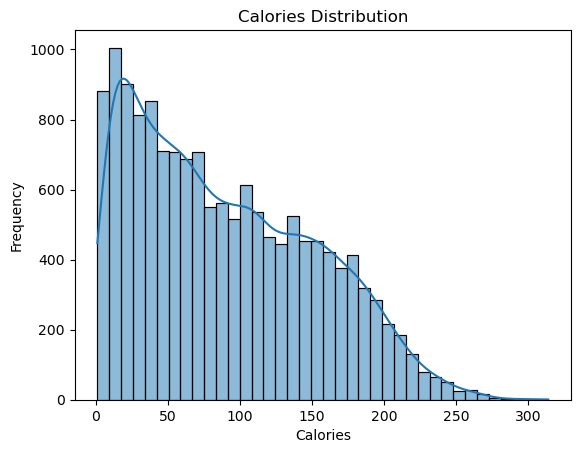

In [6]:
for feature in ['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp', 'Calories']:
    sns.histplot(df[feature], kde=True)
    plt.title(f'{feature} Distribution')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.show()

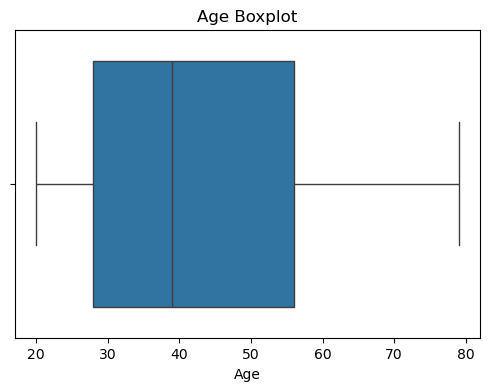

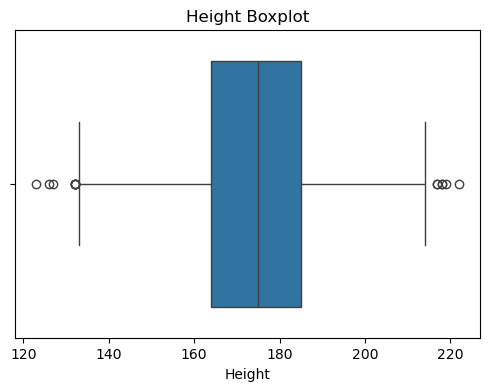

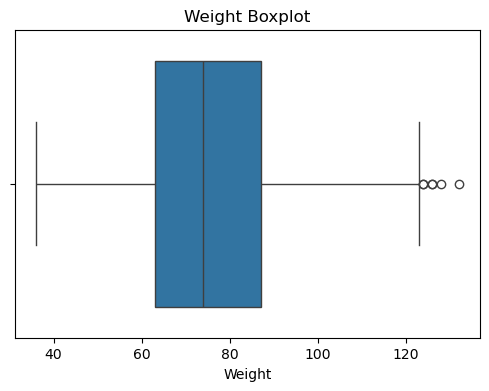

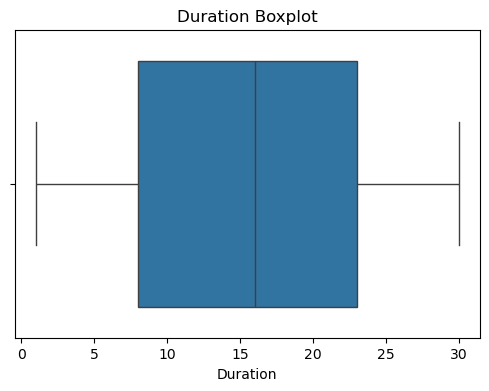

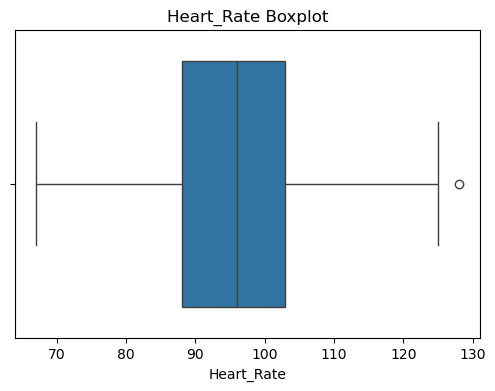

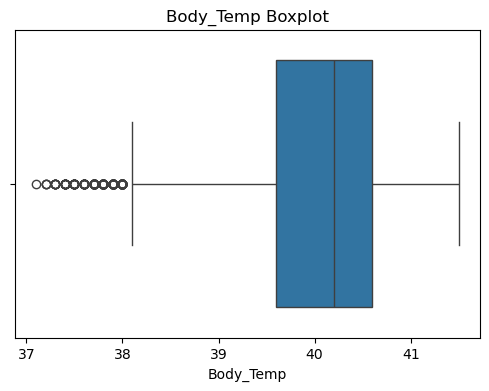

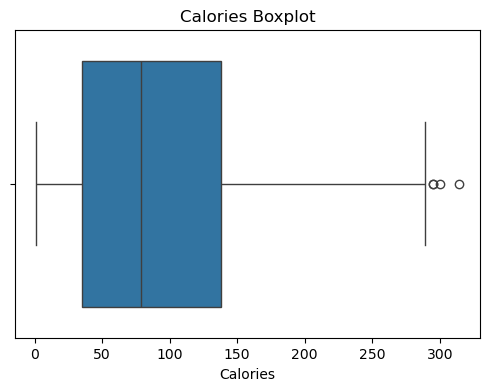

In [7]:
for feature in ['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp', 'Calories']:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[feature])
    plt.title(f'{feature} Boxplot')
    plt.xlabel(feature)
    plt.show()

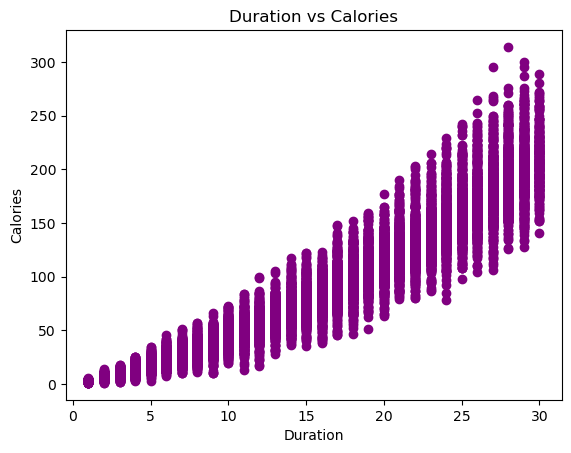

In [8]:
plt.scatter(df['Duration'], df['Calories'], color='purple')
plt.title('Duration vs Calories')
plt.xlabel('Duration')
plt.ylabel('Calories')
plt.show()

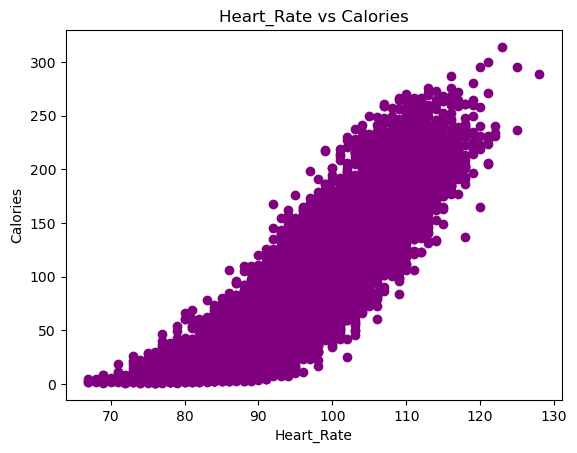

In [9]:
plt.scatter(df['Heart_Rate'], df['Calories'], color='purple')
plt.title('Heart_Rate vs Calories')
plt.xlabel('Heart_Rate')
plt.ylabel('Calories')
plt.show()

In [10]:
numerical_cols = ['Age','Height','Weight','Duration','Heart_Rate','Body_Temp','Calories']

print("Shape before removing outliers:", df.shape)

for col in numerical_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower_limit) & (df[col] <= upper_limit)]

print("Shape after removing outliers:", df.shape)

Shape before removing outliers: (15000, 9)
Shape after removing outliers: (14611, 9)


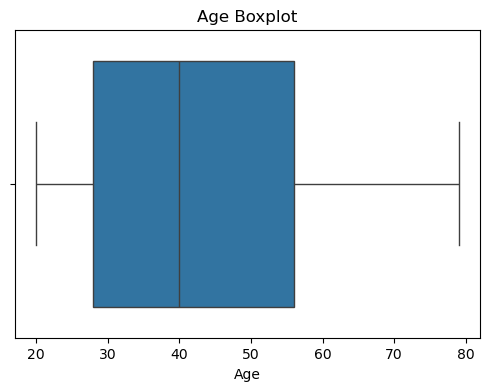

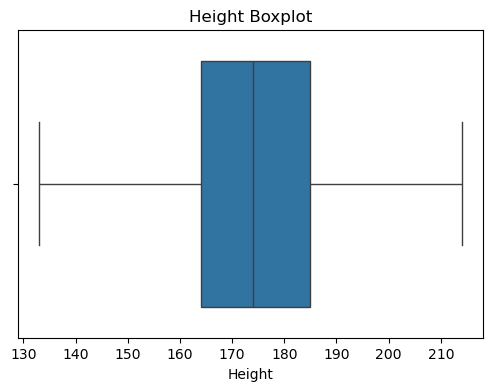

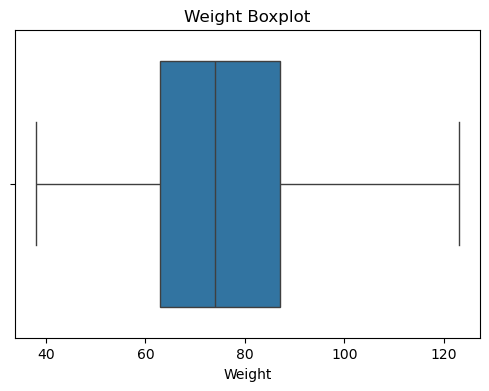

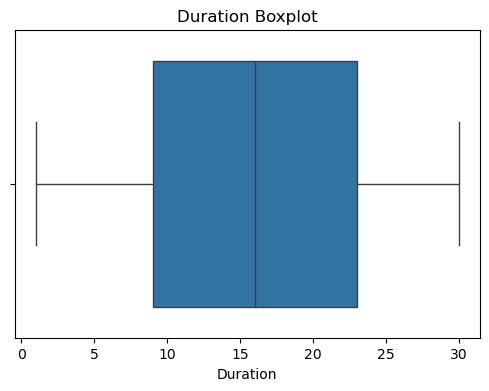

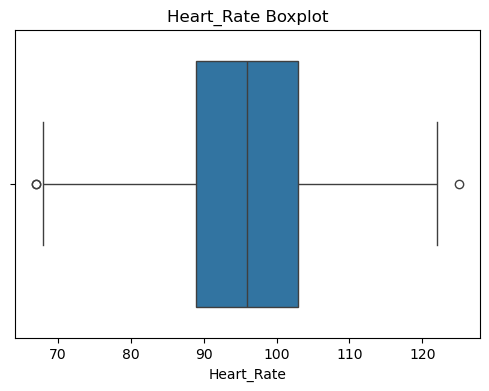

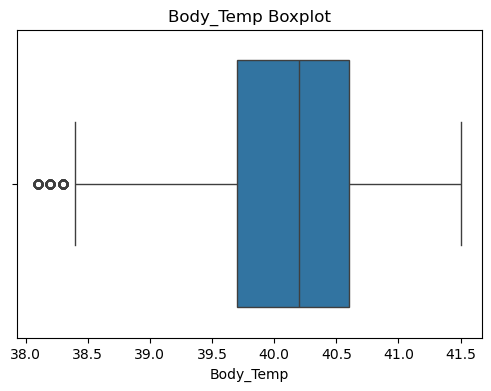

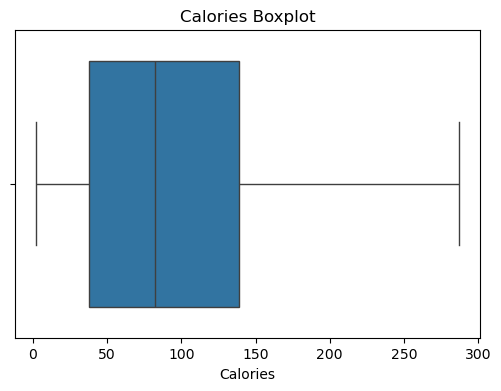

In [11]:
for feature in ['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp', 'Calories']:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[feature])
    plt.title(f'{feature} Boxplot')
    plt.xlabel(feature)
    plt.show()

In [12]:
df = pd.get_dummies(df, columns=['Gender'], drop_first=True)

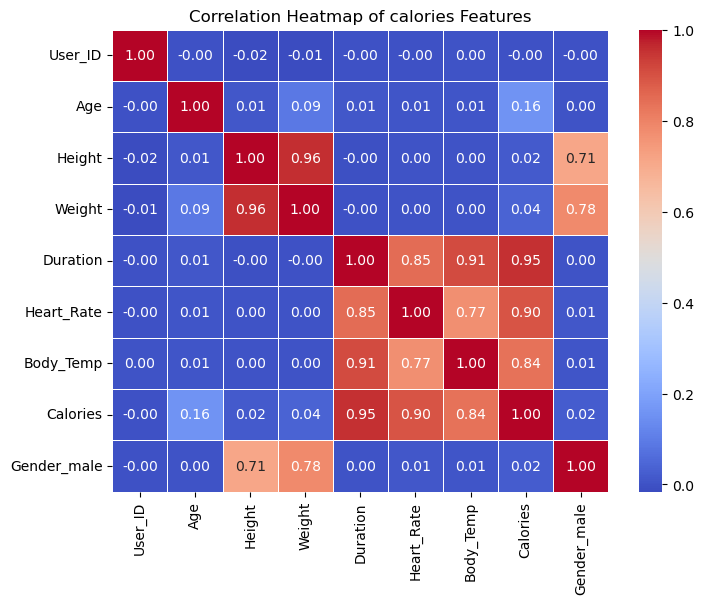

In [13]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of calories Features')
plt.show()

In [14]:
df.isnull().sum()

User_ID        0
Age            0
Height         0
Weight         0
Duration       0
Heart_Rate     0
Body_Temp      0
Calories       0
Gender_male    0
dtype: int64

In [15]:
df = df.drop(columns=['User_ID'])

In [18]:
from sklearn.model_selection import train_test_split

X = df.drop('Calories', axis=1)
y = df['Calories']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [19]:
from sklearn.preprocessing import StandardScaler

num_cols = ['Age','Height','Weight','Duration','Heart_Rate','Body_Temp']

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

R2: 0.9663999943147896


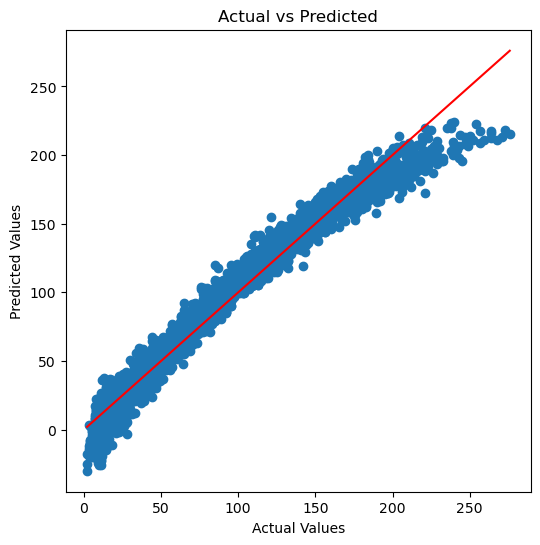

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)


r2_lr = r2_score(y_test, y_pred)
print("R2:", r2_lr)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

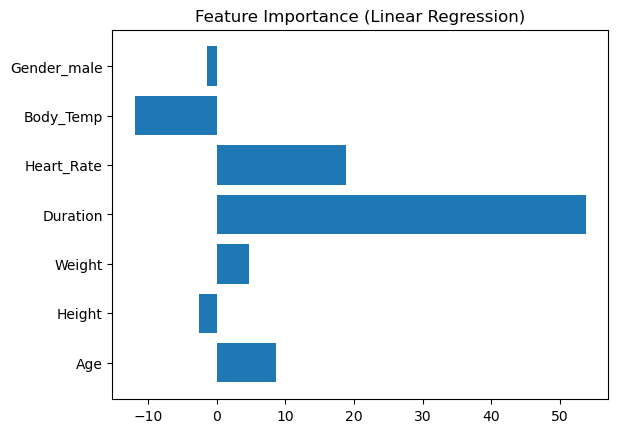

In [21]:
features = X.columns
coeffs = lr.coef_

plt.barh(features, coeffs)
plt.title("Feature Importance (Linear Regression)")
plt.show()

Gradient Descent R2: 0.9662036726640383


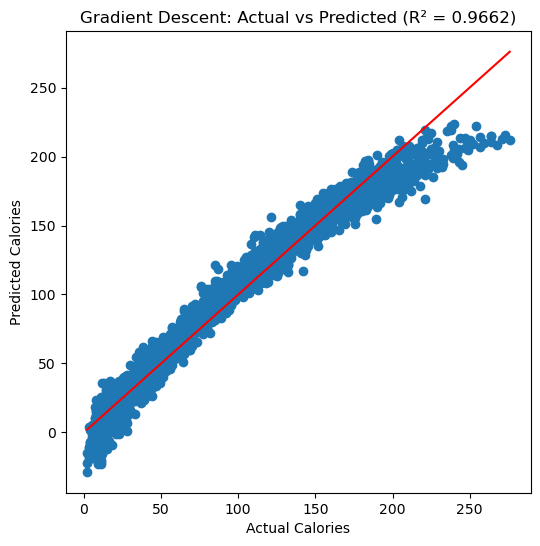

In [22]:
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

gd_model = SGDRegressor(
    max_iter=1000,
    learning_rate='constant',
    eta0=0.01,
    random_state=42
)

gd_model.fit(X_train, y_train)

y_pred_gd = gd_model.predict(X_test)

r2_gd = r2_score(y_test, y_pred_gd)
print("Gradient Descent R2:", r2_gd)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_gd)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)
plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories")
plt.title(f"Gradient Descent: Actual vs Predicted (R² = {r2_gd:.4f})")
plt.show()

Ridge R2: 0.9663998230041929


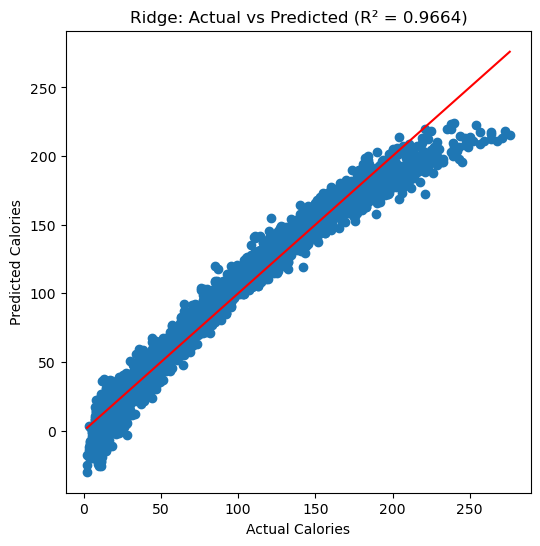

In [23]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

r2_ridge = r2_score(y_test, y_pred_ridge)
print("Ridge R2:", r2_ridge)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_ridge)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)
plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories")
plt.title(f"Ridge: Actual vs Predicted (R² = {r2_ridge:.4f})")
plt.show()

Number of zero coefficients: 2
Lasso R2: 0.9661898866921601


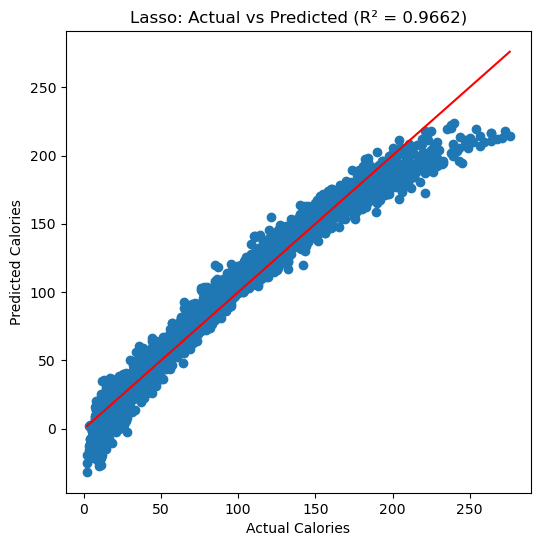

In [28]:
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

lasso = Lasso(alpha=0.01)

lasso = Lasso(alpha=0.1)

lasso.fit(X_train, y_train)

print("Number of zero coefficients:", np.sum(lasso.coef_ == 0))

y_pred_lasso = lasso.predict(X_test)

r2_lasso = r2_score(y_test, y_pred_lasso)
print("Lasso R2:", r2_lasso)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_lasso)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)
plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories")
plt.title(f"Lasso: Actual vs Predicted (R² = {r2_lasso:.4f})")
plt.show()

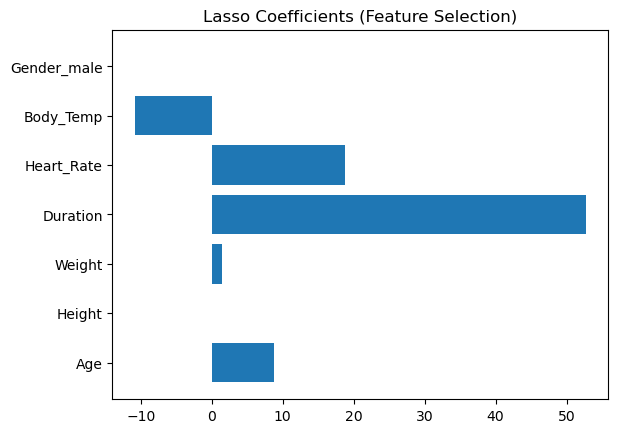

In [32]:
plt.barh(X.columns, lasso.coef_)
plt.title("Lasso Coefficients (Feature Selection)")
plt.show()

ElasticNet R2: 0.9662170920793572


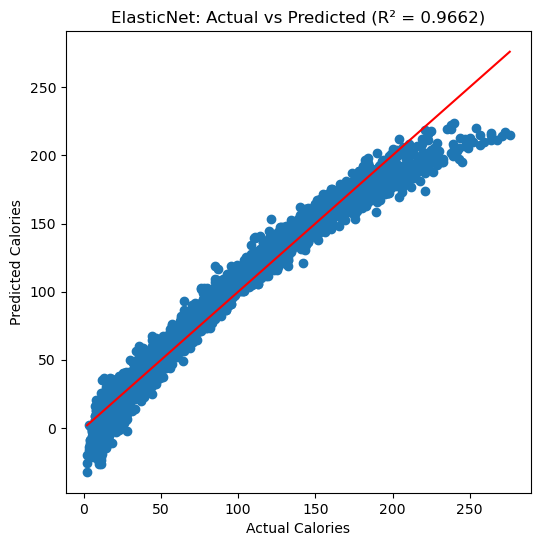

In [30]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

elastic = ElasticNet(alpha=0.01, l1_ratio=0.5)

elastic.fit(X_train, y_train)

y_pred_elastic = elastic.predict(X_test)

r2_elastic = r2_score(y_test, y_pred_elastic)
print("ElasticNet R2:", r2_elastic)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_elastic)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)
plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories")
plt.title(f"ElasticNet: Actual vs Predicted (R² = {r2_elastic:.4f})")
plt.show()

In [31]:
results = pd.DataFrame({
    "Model": ["Linear Regression (Normal Equation)","Linear Regression (Gradient Descent)", "Ridge Regression", "Lasso Regression", "Elastic Net"],
    "R2 Score": [r2_lr, r2_gd ,r2_ridge ,r2_lasso ,r2_elastic]
})
results

,Model,R2 Score
0,Linear Regression (Normal Equation),0.966400
1,Linear Regression (Gradient Descent),0.966204
2,Ridge Regression,0.966400
3,Lasso Regression,0.966190
4,Elastic Net,0.966217
